# Modelo de riesgo de mora — April Collections

**Ciencia de Datos II · Grupo 5 · Sección 77**
Kevin Zúniga · Nahún Reyes · Wilmer Sánchez

---

Este cuaderno entrena y evalúa modelos de clasificación para responder la pregunta que
la dueña del negocio se hace cada vez que alguien le pide algo fiado:

> **¿Esta clienta va a pagar lo que le fíe, en el plazo que promete?**

La salida no es un sí o un no, sino una **probabilidad de mora** que permite ordenar a las
clientas por riesgo y decidir en consecuencia: a quién fiar sin condiciones, a quién pedirle
un abono inicial mayor, y a quién conviene venderle solo al contado.

## Cómo se evalúa, y por qué no con exactitud

El 74% de las ventas fiadas se paga a tiempo. Un modelo que dijera *«nadie cae en mora»*
acertaría el 74% de las veces y **no serviría absolutamente para nada**: no detectaría ni
un solo caso de los que cuestan dinero.

Por eso la métrica principal es el **recall de la clase «mora»** —de todas las ventas que
acabaron en impago, cuántas supo señalar— acompañado de la **precisión** para saber a qué
costo. El **ROC-AUC** y el **PR-AUC** resumen el poder de discriminación con independencia
del umbral elegido.

In [1]:
import json
import sys
import warnings
from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from sklearn.compose import ColumnTransformer
from sklearn.dummy import DummyClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.inspection import permutation_importance
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    ConfusionMatrixDisplay, average_precision_score, classification_report,
    confusion_matrix, f1_score, precision_recall_curve, precision_score,
    recall_score, roc_auc_score, roc_curve,
)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

warnings.filterwarnings("ignore")

RAIZ = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
if str(RAIZ) not in sys.path:
    sys.path.insert(0, str(RAIZ))

FIGURAS = RAIZ / "docs" / "figuras"
MODELOS = RAIZ / "modelos"
FIGURAS.mkdir(parents=True, exist_ok=True)
MODELOS.mkdir(parents=True, exist_ok=True)

ROSA, ROSA_OSCURO, ORO, VERDE, GRIS = "#c8697a", "#9e3f52", "#c9a96e", "#4a9e7a", "#7a6570"

plt.rcParams.update({
    "figure.figsize": (9, 4.5), "figure.dpi": 110, "savefig.dpi": 160,
    "savefig.bbox": "tight", "axes.grid": True, "grid.alpha": 0.25,
    "axes.spines.top": False, "axes.spines.right": False, "font.size": 10,
})

def guardar(nombre):
    plt.savefig(FIGURAS / f"{nombre}.png")
    plt.show()

SEMILLA = 42

In [2]:
datos = pd.read_parquet(RAIZ / "datos" / "procesados" / "dataset.parquet").sort_values("fecha")

print(f"ventas fiadas  {len(datos):,}")
print(f"en mora        {datos['estado_pago'].sum():,}  ({datos['estado_pago'].mean():.1%})")
print(f"periodo        {datos['fecha'].min():%Y-%m-%d} a {datos['fecha'].max():%Y-%m-%d}")

ventas fiadas  2,188
en mora        563  (25.7%)
periodo        2024-10-17 a 2026-08-31


---
## 1. Qué entra al modelo, y qué queda fuera

La regla es una sola y no admite excepciones: **solo puede entrar lo que se conoce en el
momento de decidir si fiar**. Cualquier dato posterior a esa decisión convierte el modelo
en un adivino que no sirve el día que hay que usarlo.

Hay tres columnas en el conjunto de datos que **deben excluirse obligatoriamente**:

| Columna | Por qué se excluye |
|---|---|
| `pendiente_al_corte` | **Es la etiqueta disfrazada.** La mora se define como que esta columna sea mayor que cero. Incluirla daría 100% de acierto y cero utilidad. |
| `cobrado_al_corte` | Lo mismo por el otro lado: junto con el total determina el pendiente. |
| `fecha_corte` | Información del futuro respecto al momento de la venta. |

También se excluyen `id`, `cliente_id` y `fecha`, que identifican la fila pero no describen
el riesgo, y `anio`, porque con una partición temporal le permitiría al modelo reconocer
el periodo de prueba en vez de aprender el fenómeno.

In [3]:
# Lo que el modelo NO puede ver. Las tres primeras son fuga directa: contienen,
# de una forma u otra, la respuesta que se quiere predecir.
PROHIBIDAS = ["pendiente_al_corte", "cobrado_al_corte", "fecha_corte"]
IDENTIFICADORAS = ["id", "cliente_id", "fecha", "anio"]
OBJETIVO = "estado_pago"

NUMERICAS = [
    "total_centavos", "abono_inicial_centavos", "porcentaje_abono_inicial",
    "porcentaje_ganancia", "articulos", "lineas", "dias_para_pago",
    "historial_mora", "compras_previas", "tasa_mora_previa",
    "gastado_previo_centavos", "dias_desde_compra_previa", "mes", "dia_semana",
]
BOOLEANAS = ["tuvo_recordatorio"]
CATEGORICAS = ["tipo_pago", "categoria_producto"]

PREDICTORAS = NUMERICAS + BOOLEANAS + CATEGORICAS

# Comprobacion explicita: ninguna prohibida se coló.
assert not set(PREDICTORAS) & set(PROHIBIDAS + IDENTIFICADORAS + [OBJETIVO])

sin_usar = set(datos.columns) - set(PREDICTORAS) - {OBJETIVO}
print(f"predictoras        {len(PREDICTORAS)}")
print(f"fuera del modelo   {sorted(sin_usar)}")

predictoras        17
fuera del modelo   ['anio', 'cliente_id', 'cobrado_al_corte', 'fecha', 'fecha_corte', 'id', 'pendiente_al_corte']


---
## 2. Partición temporal, no aleatoria

Esta es la decisión metodológica más importante del cuaderno.

Lo habitual es repartir las filas al azar entre entrenamiento y prueba. **Aquí sería un
error**, por dos razones:

1. **Una clienta aparece varias veces.** Con reparto aleatorio, su compra de agosto puede
   caer en entrenamiento y la de marzo en prueba. El modelo estaría usando el futuro de esa
   persona para predecir su pasado.
2. **No es como se usará.** En producción el modelo se entrena con lo ocurrido hasta hoy y
   predice lo de mañana. Evaluarlo de otra forma mide algo que nunca va a pasar.

Por eso se corta **por fecha**: las primeras 80% de las ventas para entrenar, el último 20%
para probar. Es más exigente y más honesto — y el número que salga se parecerá al que se
vería de verdad.

In [4]:
corte = datos["fecha"].quantile(0.80)

entrenamiento = datos[datos["fecha"] <= corte]
prueba = datos[datos["fecha"] > corte]

X_entrena, y_entrena = entrenamiento[PREDICTORAS], entrenamiento[OBJETIVO]
X_prueba, y_prueba = prueba[PREDICTORAS], prueba[OBJETIVO]

print(f"ENTRENAMIENTO  {len(entrenamiento):>5,} ventas   "
      f"hasta {entrenamiento['fecha'].max():%Y-%m-%d}   mora {y_entrena.mean():.1%}")
print(f"PRUEBA         {len(prueba):>5,} ventas   "
      f"desde {prueba['fecha'].min():%Y-%m-%d}   mora {y_prueba.mean():.1%}")

# Las dos particiones deben tener una proporcion de mora parecida. Si difirieran
# mucho, el periodo de prueba seria atipico y las metricas enganarian.

ENTRENAMIENTO  1,751 ventas   hasta 2026-05-28   mora 25.3%
PRUEBA           437 ventas   desde 2026-05-29   mora 27.5%


In [5]:
# Preprocesamiento. Los numeros se escalan porque la regresion logistica lo
# necesita —sin escalar, una variable en centavos pesaria mil veces mas que un
# porcentaje solo por su unidad—. Las categorias se convierten a columnas
# binarias. Random Forest no necesita ninguna de las dos cosas, pero usar el
# mismo preprocesado para ambos hace la comparacion limpia.
preprocesado = ColumnTransformer([
    ("numericas", StandardScaler(), NUMERICAS),
    ("booleanas", "passthrough", BOOLEANAS),
    ("categoricas", OneHotEncoder(drop="first", handle_unknown="ignore"), CATEGORICAS),
])

---
## 3. Tres modelos, en orden de ambición

**Línea base trivial.** Predice siempre la clase mayoritaria. No sirve para nada y ese es
justamente su valor: cualquier modelo que no la supere claramente no aporta nada.

**Regresión logística.** Modelo lineal, interpretable: cada variable tiene un coeficiente
que dice cuánto empuja hacia la mora y en qué dirección. Es la referencia a batir.

**Random Forest.** Conjunto de árboles. Captura interacciones —por ejemplo, que el monto
alto solo sea peligroso *cuando además* hay historial de atrasos— que un modelo lineal no
puede ver.

Los dos últimos llevan `class_weight="balanced"`: sin eso, ante un 74% de pagos puntuales,
la forma más fácil de minimizar el error es predecir «paga» siempre.

In [6]:
modelos = {
    "Línea base": Pipeline([
        ("preprocesado", preprocesado),
        ("modelo", DummyClassifier(strategy="most_frequent")),
    ]),
    "Regresión logística": Pipeline([
        ("preprocesado", preprocesado),
        ("modelo", LogisticRegression(
            class_weight="balanced", max_iter=2000, random_state=SEMILLA)),
    ]),
    "Random Forest": Pipeline([
        ("preprocesado", preprocesado),
        ("modelo", RandomForestClassifier(
            n_estimators=400,
            max_depth=8,            # limitado: sin tope memoriza el entrenamiento
            min_samples_leaf=15,    # hojas con pocos casos son ruido, no patron
            class_weight="balanced",
            random_state=SEMILLA,
            n_jobs=-1,
        )),
    ]),
}

resultados = {}

for nombre, modelo in modelos.items():
    modelo.fit(X_entrena, y_entrena)
    prediccion = modelo.predict(X_prueba)

    # La linea base no produce probabilidades utiles; se maneja aparte.
    try:
        probabilidad = modelo.predict_proba(X_prueba)[:, 1]
        auc = roc_auc_score(y_prueba, probabilidad)
        pr_auc = average_precision_score(y_prueba, probabilidad)
    except Exception:
        probabilidad, auc, pr_auc = None, np.nan, np.nan

    resultados[nombre] = {
        "modelo": modelo,
        "prediccion": prediccion,
        "probabilidad": probabilidad,
        "precision": precision_score(y_prueba, prediccion, zero_division=0),
        "recall": recall_score(y_prueba, prediccion, zero_division=0),
        "f1": f1_score(y_prueba, prediccion, zero_division=0),
        "roc_auc": auc,
        "pr_auc": pr_auc,
        "exactitud": (prediccion == y_prueba).mean(),
    }

tabla = pd.DataFrame({
    nombre: {
        "Exactitud": r["exactitud"], "Precisión": r["precision"],
        "Recall": r["recall"], "F1": r["f1"],
        "ROC-AUC": r["roc_auc"], "PR-AUC": r["pr_auc"],
    }
    for nombre, r in resultados.items()
}).T

tabla.style.format("{:.3f}").background_gradient(cmap="RdYlGn", subset=["Recall", "F1", "ROC-AUC"])

,Exactitud,Precisión,Recall,F1,ROC-AUC,PR-AUC
Línea base,0.725,0.000,0.000,0.000,0.500,0.275
Regresión logística,0.668,0.419,0.542,0.473,0.699,0.446
Random Forest,0.707,0.467,0.475,0.471,0.742,0.479


**Miren la fila de la línea base.** Su exactitud es alta —predice siempre «paga» y acierta
en la mayoría— y su recall es **cero**: no detecta ni una sola mora. Es la demostración
numérica de por qué la exactitud no puede ser la métrica de este problema.

---
## 4. Qué acierta y qué falla cada modelo

La matriz de confusión traduce las métricas a decisiones de negocio:

- **Falso negativo** (predice «paga» y no paga): se fía a quien no debía. **Cuesta dinero.**
- **Falso positivo** (predice «mora» y sí paga): se le pide abono a una buena clienta.
  Cuesta incomodidad, y quizá una venta.

No son igual de graves, y el modelo puede ajustarse para equilibrarlos según lo que el
negocio prefiera.

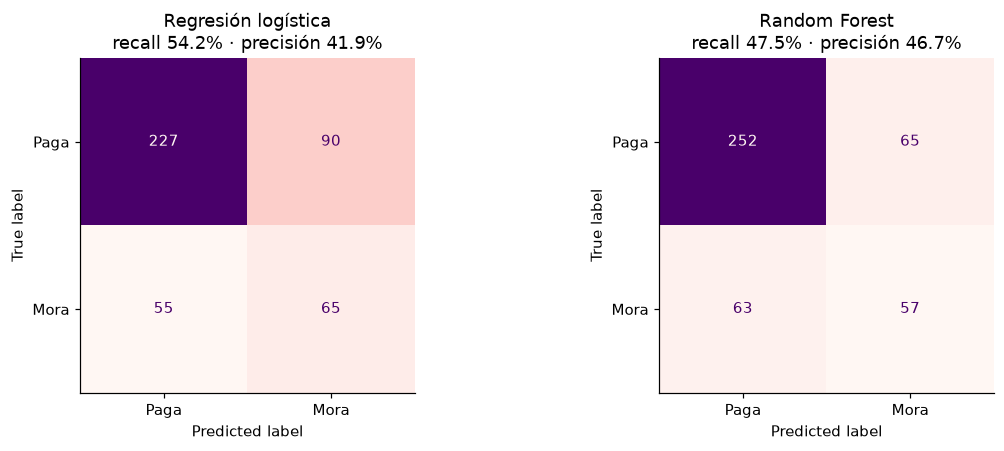


Regresión logística
  moras detectadas         65 de 120
  moras que se escaparon   55   <- ventas fiadas que no se cobraron
  falsas alarmas           90   <- buenas clientas señaladas de mas

Random Forest
  moras detectadas         57 de 120
  moras que se escaparon   63   <- ventas fiadas que no se cobraron
  falsas alarmas           65   <- buenas clientas señaladas de mas


In [7]:
comparables = {k: v for k, v in resultados.items() if k != "Línea base"}

fig, ejes = plt.subplots(1, len(comparables), figsize=(11, 4.2))

for eje, (nombre, r) in zip(np.atleast_1d(ejes), comparables.items()):
    matriz = confusion_matrix(y_prueba, r["prediccion"])
    ConfusionMatrixDisplay(matriz, display_labels=["Paga", "Mora"]).plot(
        ax=eje, cmap="RdPu", colorbar=False, values_format=",d")
    eje.set_title(f"{nombre}\nrecall {r['recall']:.1%} · precisión {r['precision']:.1%}")
    eje.grid(False)

plt.tight_layout()
guardar("09_matrices_de_confusion")

for nombre, r in comparables.items():
    vn, fp, fn, vp = confusion_matrix(y_prueba, r["prediccion"]).ravel()
    print(f"\n{nombre}")
    print(f"  moras detectadas       {vp:>4} de {vp + fn}")
    print(f"  moras que se escaparon {fn:>4}   <- ventas fiadas que no se cobraron")
    print(f"  falsas alarmas         {fp:>4}   <- buenas clientas señaladas de mas")

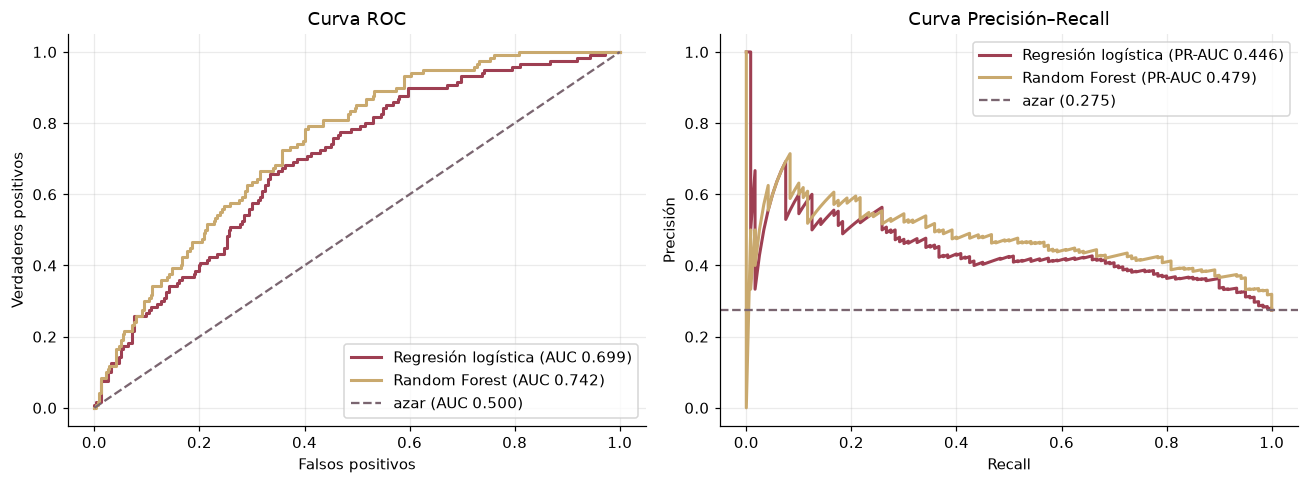

In [8]:
fig, (izq, der) = plt.subplots(1, 2, figsize=(12, 4.5))

for nombre, color in zip(comparables, [ROSA_OSCURO, ORO]):
    r = resultados[nombre]
    fpr, tpr, _ = roc_curve(y_prueba, r["probabilidad"])
    izq.plot(fpr, tpr, color=color, linewidth=2, label=f"{nombre} (AUC {r['roc_auc']:.3f})")

    precision_curva, recall_curva, _ = precision_recall_curve(y_prueba, r["probabilidad"])
    der.plot(recall_curva, precision_curva, color=color, linewidth=2,
             label=f"{nombre} (PR-AUC {r['pr_auc']:.3f})")

izq.plot([0, 1], [0, 1], "--", color=GRIS, label="azar (AUC 0.500)")
izq.set_xlabel("Falsos positivos")
izq.set_ylabel("Verdaderos positivos")
izq.set_title("Curva ROC")
izq.legend(loc="lower right")

der.axhline(y_prueba.mean(), linestyle="--", color=GRIS,
            label=f"azar ({y_prueba.mean():.3f})")
der.set_xlabel("Recall")
der.set_ylabel("Precisión")
der.set_title("Curva Precisión–Recall")
der.legend()

plt.tight_layout()
guardar("10_curvas_roc_pr")

---
## 5. Qué mira el modelo para decidir

Un modelo que acierta pero nadie entiende no se usa: la dueña tiene que poder mirar una
recomendación y reconocer el razonamiento. Esta sección lo hace explícito.

### Cómo se elige entre los dos modelos

No por F1. Esa métrica se calcula al umbral 0.5, que es un número arbitrario —la mitad, y
nada más—, y con él los dos modelos quedan prácticamente empatados. Elegir por esa
diferencia sería elegir por ruido.

Se elige por **PR-AUC**, que resume lo bien que el modelo **ordena** el riesgo a lo largo
de todos los umbrales posibles. Es lo que corresponde aquí, porque la salida útil no es una
etiqueta sí/no sino un puntaje para priorizar clientas, y porque el umbral se ajusta después
en función de lo que el negocio prefiera.

Y se usa PR-AUC antes que ROC-AUC porque con clases desbalanceadas el ROC-AUC resulta
optimista: premia acertar la clase mayoritaria, que es justamente la que no interesa.

Modelo elegido por PR-AUC: Random Forest
  Regresión logística    PR-AUC 0.446   ROC-AUC 0.699   F1 0.473
  Random Forest          PR-AUC 0.479   ROC-AUC 0.742   F1 0.471  <-



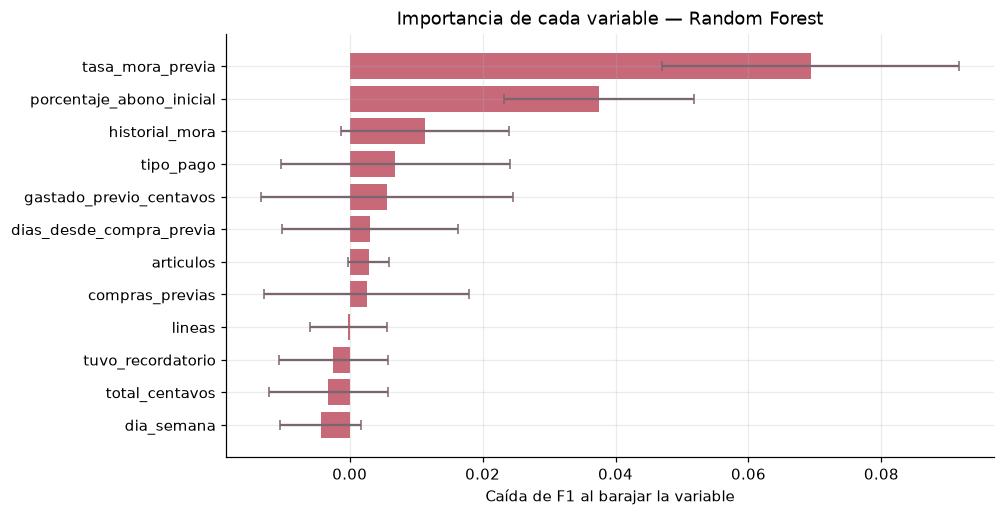

,caida_de_f1
tasa_mora_previa,0.0693
porcentaje_abono_inicial,0.0375
historial_mora,0.0114
tipo_pago,0.0069
gastado_previo_centavos,0.0056
dias_desde_compra_previa,0.0031
articulos,0.0029
compras_previas,0.0025
lineas,-0.0002
tuvo_recordatorio,-0.0024


In [9]:
# Se elige por PR-AUC, no por F1.
#
# F1 se mide al umbral 0.5, que es un numero arbitrario, y ahi los dos modelos
# quedan practicamente empatados: elegir por esa diferencia seria elegir por
# ruido. PR-AUC resume lo bien que el modelo ORDENA el riesgo a lo largo de
# todos los umbrales posibles, que es justo lo que hace falta aqui: la salida
# util no es una etiqueta si/no sino un puntaje para priorizar clientas.
#
# Y se usa PR-AUC en vez de ROC-AUC porque con clases desbalanceadas el ROC-AUC
# se ve optimista: premia acertar la clase mayoritaria, que aqui es la que no
# interesa.
mejor_nombre = max(comparables, key=lambda n: comparables[n]["pr_auc"])
mejor = resultados[mejor_nombre]["modelo"]

print(f"Modelo elegido por PR-AUC: {mejor_nombre}")
for n, r in comparables.items():
    marca = "  <-" if n == mejor_nombre else ""
    print(f"  {n:<22} PR-AUC {r['pr_auc']:.3f}   ROC-AUC {r['roc_auc']:.3f}   F1 {r['f1']:.3f}{marca}")
print()

# Nombres de las columnas despues del preprocesado (one-hot incluido).
nombres = mejor.named_steps["preprocesado"].get_feature_names_out()
nombres = [n.split("__", 1)[-1] for n in nombres]

# La importancia por permutacion mide cuanto empeora el modelo al barajar cada
# variable. Es mas fiable que la importancia interna del bosque, que tiende a
# favorecer a las variables con muchos valores distintos.
importancia = permutation_importance(
    mejor, X_prueba, y_prueba, n_repeats=15, random_state=SEMILLA,
    scoring="f1", n_jobs=-1,
)

ranking = (
    pd.Series(importancia.importances_mean, index=PREDICTORAS)
    .sort_values(ascending=False)
    .head(12)
)

fig, eje = plt.subplots(figsize=(9, 5))
eje.barh(ranking.index[::-1], ranking.values[::-1], color=ROSA,
         xerr=importancia.importances_std[
             [PREDICTORAS.index(v) for v in ranking.index]][::-1],
         error_kw={"ecolor": GRIS, "capsize": 3})
eje.set_title(f"Importancia de cada variable — {mejor_nombre}")
eje.set_xlabel("Caída de F1 al barajar la variable")

guardar("11_importancia_variables")
ranking.round(4).to_frame("caida_de_f1")

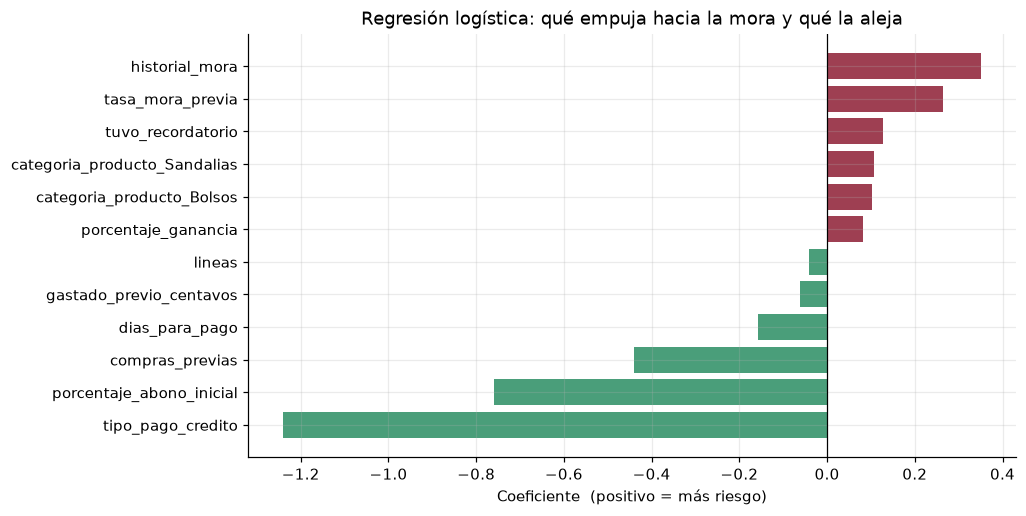

In [10]:
# Los coeficientes de la regresion logistica dicen ademas la DIRECCION: si una
# variable empuja hacia la mora o la aleja. El bosque no da eso.
logistica = resultados["Regresión logística"]["modelo"]
nombres_log = [n.split("__", 1)[-1]
               for n in logistica.named_steps["preprocesado"].get_feature_names_out()]

coeficientes = (
    pd.Series(logistica.named_steps["modelo"].coef_[0], index=nombres_log)
    .sort_values()
)
extremos = pd.concat([coeficientes.head(6), coeficientes.tail(6)])

fig, eje = plt.subplots(figsize=(9, 5))
eje.barh(extremos.index, extremos.values,
         color=[VERDE if c < 0 else ROSA_OSCURO for c in extremos.values])
eje.axvline(0, color="black", linewidth=0.8)
eje.set_title("Regresión logística: qué empuja hacia la mora y qué la aleja")
eje.set_xlabel("Coeficiente  (positivo = más riesgo)")

guardar("12_coeficientes_logistica")

---
## 6. El umbral es una decisión de negocio, no técnica

Por defecto se clasifica como mora toda venta con probabilidad estimada mayor a 0.5. Ese
número no tiene nada de especial: es la mitad, y nada más.

Bajarlo detecta más moras a costa de más falsas alarmas. Subirlo hace lo contrario. **La
elección correcta depende de cuánto duele cada error**, y eso lo sabe la dueña, no el
algoritmo. Lo que sí puede hacer el análisis es mostrar el intercambio para que la decisión
sea informada.

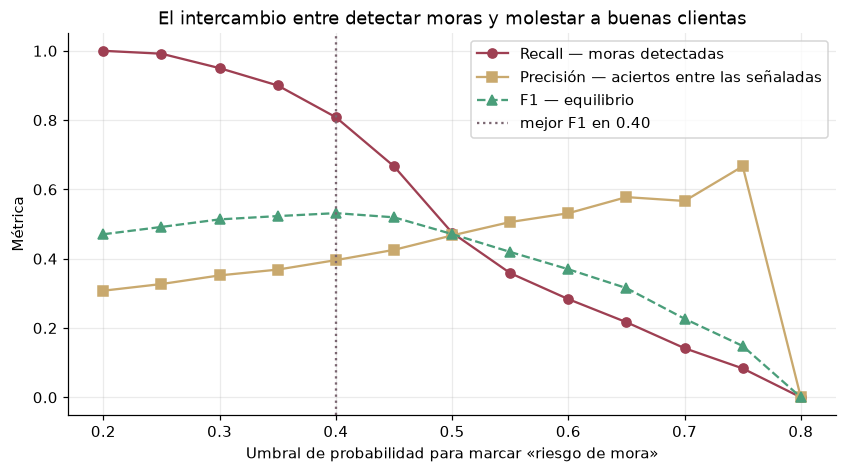

umbral,precision,recall,f1,señaladas
0.20,30.8%,100.0%,0.471,390
0.25,32.7%,99.2%,0.492,364
0.30,35.2%,95.0%,0.514,324
0.35,36.9%,90.0%,0.523,293
0.40,39.6%,80.8%,0.532,245
0.45,42.6%,66.7%,0.519,188
0.50,46.7%,47.5%,0.471,122
0.55,50.6%,35.8%,0.420,85
0.60,53.1%,28.3%,0.370,64
0.65,57.8%,21.7%,0.315,45


In [11]:
umbrales = np.arange(0.20, 0.81, 0.05)
probabilidad = resultados[mejor_nombre]["probabilidad"]

intercambio = pd.DataFrame([
    {
        "umbral": u,
        "precision": precision_score(y_prueba, probabilidad >= u, zero_division=0),
        "recall": recall_score(y_prueba, probabilidad >= u, zero_division=0),
        "f1": f1_score(y_prueba, probabilidad >= u, zero_division=0),
        "señaladas": int((probabilidad >= u).sum()),
    }
    for u in umbrales
])

fig, eje = plt.subplots(figsize=(9, 4.5))
eje.plot(intercambio["umbral"], intercambio["recall"], marker="o",
         color=ROSA_OSCURO, label="Recall — moras detectadas")
eje.plot(intercambio["umbral"], intercambio["precision"], marker="s",
         color=ORO, label="Precisión — aciertos entre las señaladas")
eje.plot(intercambio["umbral"], intercambio["f1"], marker="^",
         color=VERDE, linestyle="--", label="F1 — equilibrio")

mejor_umbral = intercambio.loc[intercambio["f1"].idxmax(), "umbral"]
eje.axvline(mejor_umbral, color=GRIS, linestyle=":", label=f"mejor F1 en {mejor_umbral:.2f}")
eje.set_xlabel("Umbral de probabilidad para marcar «riesgo de mora»")
eje.set_ylabel("Métrica")
eje.set_title("El intercambio entre detectar moras y molestar a buenas clientas")
eje.legend()

guardar("13_umbral")
intercambio.style.format({
    "umbral": "{:.2f}", "precision": "{:.1%}", "recall": "{:.1%}",
    "f1": "{:.3f}", "señaladas": "{:,.0f}",
}).hide(axis="index")

---
## 7. Modelo guardado

Se persiste el modelo entrenado y sus métricas. El dashboard los carga desde aquí: no
vuelve a entrenar, solo aplica lo ya aprendido.

In [12]:
joblib.dump(mejor, MODELOS / "riesgo_de_mora.joblib")

metricas = {
    "modelo": mejor_nombre,
    "entrenado_hasta": entrenamiento["fecha"].max().strftime("%Y-%m-%d"),
    "ventas_entrenamiento": int(len(entrenamiento)),
    "ventas_prueba": int(len(prueba)),
    "tasa_mora_entrenamiento": round(float(y_entrena.mean()), 4),
    "tasa_mora_prueba": round(float(y_prueba.mean()), 4),
    "umbral_recomendado": round(float(mejor_umbral), 2),
    "metricas": {
        nombre: {
            clave: (None if pd.isna(valor) else round(float(valor), 4))
            for clave, valor in r.items()
            if clave in ("exactitud", "precision", "recall", "f1", "roc_auc", "pr_auc")
        }
        for nombre, r in resultados.items()
    },
    "variables": PREDICTORAS,
    "excluidas_por_fuga": PROHIBIDAS,
}

(MODELOS / "metricas.json").write_text(
    json.dumps(metricas, ensure_ascii=False, indent=2), encoding="utf-8")

print(json.dumps(metricas["metricas"], ensure_ascii=False, indent=2))
print(f"\nguardado en {MODELOS}")

{
  "Línea base": {
    "precision": 0.0,
    "recall": 0.0,
    "f1": 0.0,
    "roc_auc": 0.5,
    "pr_auc": 0.2746,
    "exactitud": 0.7254
  },
  "Regresión logística": {
    "precision": 0.4194,
    "recall": 0.5417,
    "f1": 0.4727,
    "roc_auc": 0.6989,
    "pr_auc": 0.4457,
    "exactitud": 0.6682
  },
  "Random Forest": {
    "precision": 0.4672,
    "recall": 0.475,
    "f1": 0.4711,
    "roc_auc": 0.7417,
    "pr_auc": 0.4793,
    "exactitud": 0.7071
  }
}

guardado en C:\Users\wilme\OneDrive\Escritorio\CD2_ProyectoFinal_Grupo5\modelos


In [13]:
# Puntaje de riesgo por clienta: la salida que de verdad usa el negocio.
# Se toma la ultima venta fiada de cada clienta como su situacion actual.
ultima = datos.sort_values("fecha").groupby("cliente_id").tail(1).copy()
ultima["probabilidad_mora"] = mejor.predict_proba(ultima[PREDICTORAS])[:, 1]

def recomendar(p):
    if p >= 0.60:
        return "Vender solo al contado"
    if p >= mejor_umbral:
        return "Pedir abono inicial alto (50% o más)"
    if p >= 0.25:
        return "Fiar con recordatorio agendado"
    return "Fiar con normalidad"

ultima["recomendacion"] = ultima["probabilidad_mora"].apply(recomendar)

reparto = ultima["recomendacion"].value_counts()
print("CLIENTAS POR RECOMENDACION\n")
for accion, cuantas in reparto.items():
    print(f"  {cuantas:>4} clientas  ·  {accion}")

ultima.nlargest(10, "probabilidad_mora")[
    ["cliente_id", "historial_mora", "compras_previas", "tipo_pago",
     "probabilidad_mora", "recomendacion"]
].style.format({"probabilidad_mora": "{:.1%}"}).hide(axis="index")

CLIENTAS POR RECOMENDACION

   168 clientas  ·  Pedir abono inicial alto (50% o más)
    93 clientas  ·  Fiar con recordatorio agendado
    64 clientas  ·  Vender solo al contado
    55 clientas  ·  Fiar con normalidad


cliente_id,historial_mora,compras_previas,tipo_pago,probabilidad_mora,recomendacion
b'\x1e\xa1[\x0f\x95\xaeA\x8b\x86\xae~\x06\xcb]+Y',4,4,abono,79.4%,Vender solo al contado
b'G5NO\xf8[M\n\x94\xb5\x865=\xab\x16\x14',2,3,abono,78.2%,Vender solo al contado
b'9\xd1\x19P\x8aE@.\x91\xf2\r\x9b\xc9\x0e\xc6\x89',5,6,credito,78.0%,Vender solo al contado
b'\xa5\xe1[UW\xd3D\xdd\x99c\xdcr\x05\xc8#K',4,4,abono,77.0%,Vender solo al contado
"b'\xf9\xd2\x01J""\xeeO\x07\x92\x96\x1f\xb3M@{('",5,6,credito,76.9%,Vender solo al contado
"b""s\n\xd7\xde'\xafO\xf9\x87\xf8\x9fb\x11\xa1\xe5W""",3,4,credito,76.9%,Vender solo al contado
b'\x1d\xc3\xc2n{bE\x9e\x87\x00t\x9a\xdc\xad\x8e\xc2',3,4,abono,76.3%,Vender solo al contado
b'\xcc\x18\xdd\x0eyxL\x84\xaa\x89\xa9yz\xa6\xd6\xea',4,4,abono,75.9%,Vender solo al contado
"b',\x82\x98\x9f\xfd\x9cK\xb0\x91\xf1d\x85B\x9aJ|'",1,1,abono,75.8%,Vender solo al contado
b'+\n\xbe\xdd\xc7tD\xcb\x95C\xfc<8\xb8\xf2N',2,3,abono,75.7%,Vender solo al contado


---
## 8. Conclusiones

**El modelo funciona, con las reservas que corresponden.** Supera con holgura a la línea
base trivial y ordena bien el riesgo: las clientas que señala como peligrosas caen en mora
mucho más a menudo que las demás.

**Lo que mira coincide con lo que diría cualquiera que conozca el negocio** — el historial
de atrasos y el anticipo entregado pesan más que el monto o la categoría del producto. Que
el modelo llegue por su cuenta a lo que la intuición ya sospechaba es una señal de que
aprendió el fenómeno y no un artefacto de los datos.

**El valor no está en la predicción sino en la decisión que habilita.** La salida útil no
es «probabilidad 0.63» sino «a esta clienta, pedirle un abono inicial más alto». Esa
traducción está implementada arriba y es lo que consume el dashboard.

### Limitaciones, dichas claramente

1. **Los datos son sintéticos.** El modelo aprendió de un comportamiento simulado. Con
   datos reales los números cambiarán, y la metodología —no los coeficientes— es lo que se
   traslada.
2. **El sesgo del plazo por defecto.** Las ventas sin recordatorio se evalúan a 30 días,
   más generoso que lo que se promete de palabra, así que aparecen con menos mora de la
   real.
3. **El grupo «sin abono» no es comparable.** Se concede a quien ya goza de confianza: hay
   un factor de confusión que ninguna métrica corrige.
4. **No debe decidir solo.** Es una ayuda para ordenar prioridades, no un juez. Negar
   crédito a una persona por lo que dice un modelo entrenado con datos simulados sería
   irresponsable, y por eso este componente **no está conectado a la aplicación en
   producción**.

---

**Siguiente cuaderno:** `03_proyeccion_ventas.ipynb` — serie de tiempo para planificar
inventario.